<a href="https://colab.research.google.com/github/joplus2/MPA-MLF/blob/main/PC8/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN
from keras.optimizers import SGD, RMSprop, Adam, AdamW

### 1.1 Generating dataset

In [201]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [202]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [203]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [204]:
no_training_epochs = 5

### 1.3 Data examination

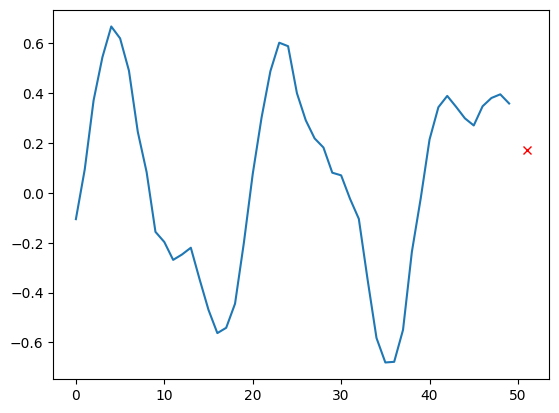

In [205]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [206]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [207]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [208]:
model_linear.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [209]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2188 - mean_squared_error: 0.2188 - val_loss: 0.1032 - val_mean_squared_error: 0.1032
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0708 - mean_squared_error: 0.0708 - val_loss: 0.0506 - val_mean_squared_error: 0.0506
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0397 - mean_squared_error: 0.0397 - val_loss: 0.0320 - val_mean_squared_error: 0.0320
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0270 - mean_squared_error: 0.0270 - val_loss: 0.0231 - val_mean_squared_error: 0.0231
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0183 - val_mean_squared_error: 0.0183


In [210]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

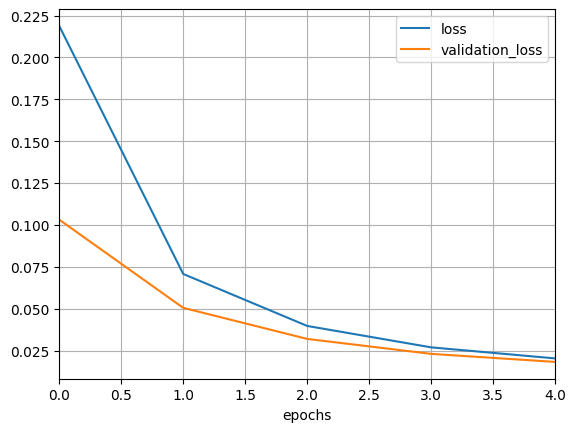

In [211]:
plot_function(history_linear)

In [212]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.01839929260313511
Test MSE:  0.01839929260313511


### 1.5 Simple RNN Model

In [213]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [214]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [215]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6842 - mean_squared_error: 0.6842 - val_loss: 0.5734 - val_mean_squared_error: 0.5734
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3959 - mean_squared_error: 0.3959 - val_loss: 0.3701 - val_mean_squared_error: 0.3701
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3112 - mean_squared_error: 0.3112 - val_loss: 0.3070 - val_mean_squared_error: 0.3070
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2649 - mean_squared_error: 0.2649 - val_loss: 0.2656 - val_mean_squared_error: 0.2656
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2282 - mean_squared_error: 0.2282 - val_loss: 0.2271 - val_mean_squared_error: 0.2271


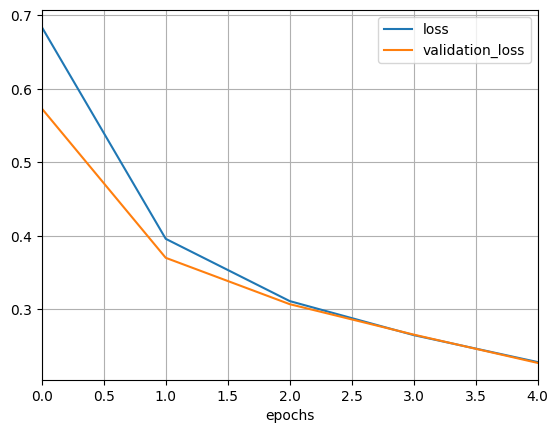

In [216]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [217]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [218]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [219]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0041 - val_mean_squared_error: 0.0041
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0034 - val_mean_squared_error: 0.0034
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0029 - val_mean_squared_error: 0.0029


In [220]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0030386049766093493
Test MSE:  0.0030386049766093493


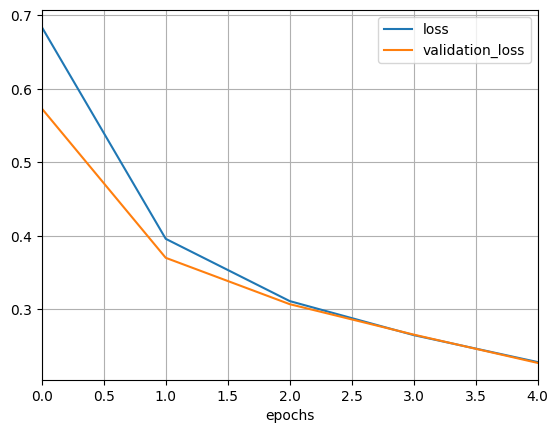

In [221]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [222]:
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

In [223]:
# set general variables
movie_epochs = 5
movie_learning = 0.001

### 2.1 - Load dataset

In [224]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

### 2.2 - Dataset examination

In [225]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [226]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [227]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [228]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [229]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid') # 1, sigmoid
    ])


In [230]:
optimizer = Adam(learning_rate = movie_learning)

In [231]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [232]:
history = model.fit(X_train, y_train, epochs=movie_epochs, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.5049 - loss: 0.7012 - val_accuracy: 0.5068 - val_loss: 0.6935
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5232 - loss: 0.6926 - val_accuracy: 0.4968 - val_loss: 0.6938
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.5233 - loss: 0.6921 - val_accuracy: 0.4938 - val_loss: 0.6940
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.5242 - loss: 0.6909 - val_accuracy: 0.5024 - val_loss: 0.6981
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.5490 - loss: 0.6837 - val_accuracy: 0.4986 - val_loss: 0.7163


Test loss: 0.7182588577270508
Test accuracy:  49.083998799324036 %


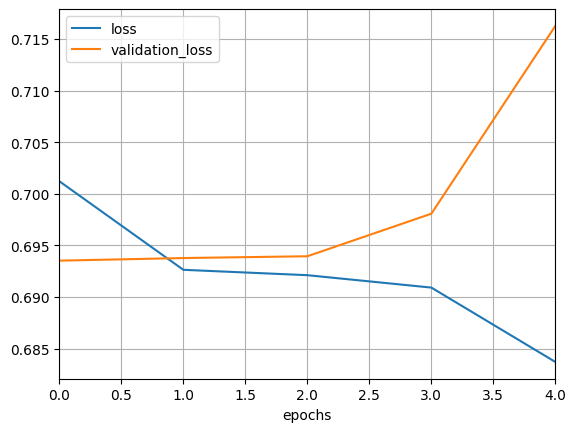

In [233]:
plot_function(history)
score_rnn = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score_rnn[0])
print(f'Test accuracy: ', score_rnn[1]*100, "%")

TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

# LSTM

In [234]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

In [235]:
optimizer = Adam(learning_rate = movie_learning)

In [236]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [237]:
history = model.fit(X_train, y_train, epochs=movie_epochs, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5786 - loss: 0.6774 - val_accuracy: 0.5872 - val_loss: 0.6790
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5880 - loss: 0.6755 - val_accuracy: 0.5486 - val_loss: 0.6835
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6197 - loss: 0.6401 - val_accuracy: 0.7720 - val_loss: 0.5136
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7940 - loss: 0.4567 - val_accuracy: 0.8060 - val_loss: 0.4307
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8242 - loss: 0.3952 - val_accuracy: 0.8098 - val_loss: 0.4121


Test loss: 0.3995196521282196
Test accuracy:  81.45999908447266 %


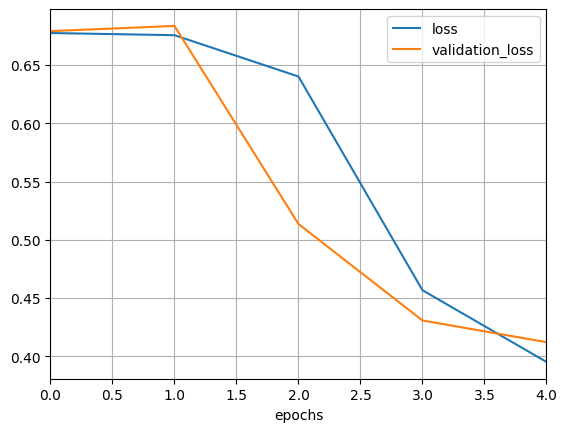

In [238]:
plot_function(history)
score_ltsm = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score_ltsm[0])
print(f'Test accuracy: ', score_ltsm[1]*100, "%")

# GRU

In [239]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])

In [240]:
optimizer = Adam(learning_rate = movie_learning)

In [241]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [242]:
history = model.fit(X_train, y_train, epochs=movie_epochs, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5926 - loss: 0.6444 - val_accuracy: 0.7748 - val_loss: 0.4756
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8110 - loss: 0.4133 - val_accuracy: 0.7850 - val_loss: 0.4619
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8417 - loss: 0.3582 - val_accuracy: 0.8290 - val_loss: 0.3972
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8571 - loss: 0.3278 - val_accuracy: 0.8368 - val_loss: 0.3803
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8666 - loss: 0.3066 - val_accuracy: 0.8328 - val_loss: 0.3913


Test loss: 0.38197192549705505
Test accuracy:  83.19600224494934 %


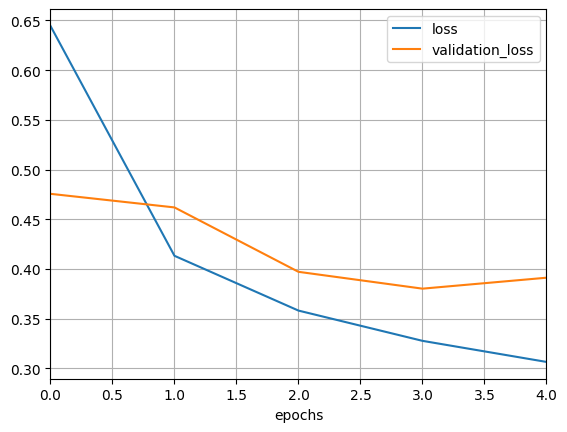

In [243]:
plot_function(history)
score_gru = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score_gru[0])
print(f'Test accuracy: ', score_gru[1]*100, "%")

# comparison

In [244]:
print("--- accuracy comparison ---")
print("RNN : {:.2f} %".format(score_rnn[1]*100))
print("LSTM: {:.2f} %".format(score_ltsm[1]*100))
print("GRU : {:.2f} %".format(score_gru[1]*100))

--- accuracy comparison ---
RNN : 49.08 %
LSTM: 81.46 %
GRU : 83.20 %


In [245]:
model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


array([[0.04905749],
       [0.9949013 ],
       [0.92643934],
       ...,
       [0.01242549],
       [0.0452158 ],
       [0.38922557]], dtype=float32)